# Gene chromatin analysis around replication

May 2, 2024

Plot the chromatin before and after replication fork passes through the gene.

**Goal:** Identify differences in chromatin when the fork passes through a gene. Identify different partitions of gene sets in which there may be patterns of differences (gene expression level, transcription vs replication direction, etc.)


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
repl_timing_file = 'datasets/computed_mnase/all_repl_timing_deconvolved.csv'
repl_timing = pd.read_csv(repl_timing_file).set_index('orf_name')
print(len(repl_timing), " genes with replication profiles")

repl_timing.head()


5250  genes with replication profiles


,timing,H_index
orf_name,,
YAL067W-A,53.314585,196
YAL067C,52.304185,194
YAL064C-A,52.809385,195
YAL064W,51.798985,193
YAL063C-A,51.798985,193


In [3]:
from src.replication_deconvolution_solver import plot_chrom_repl_timing_from_data

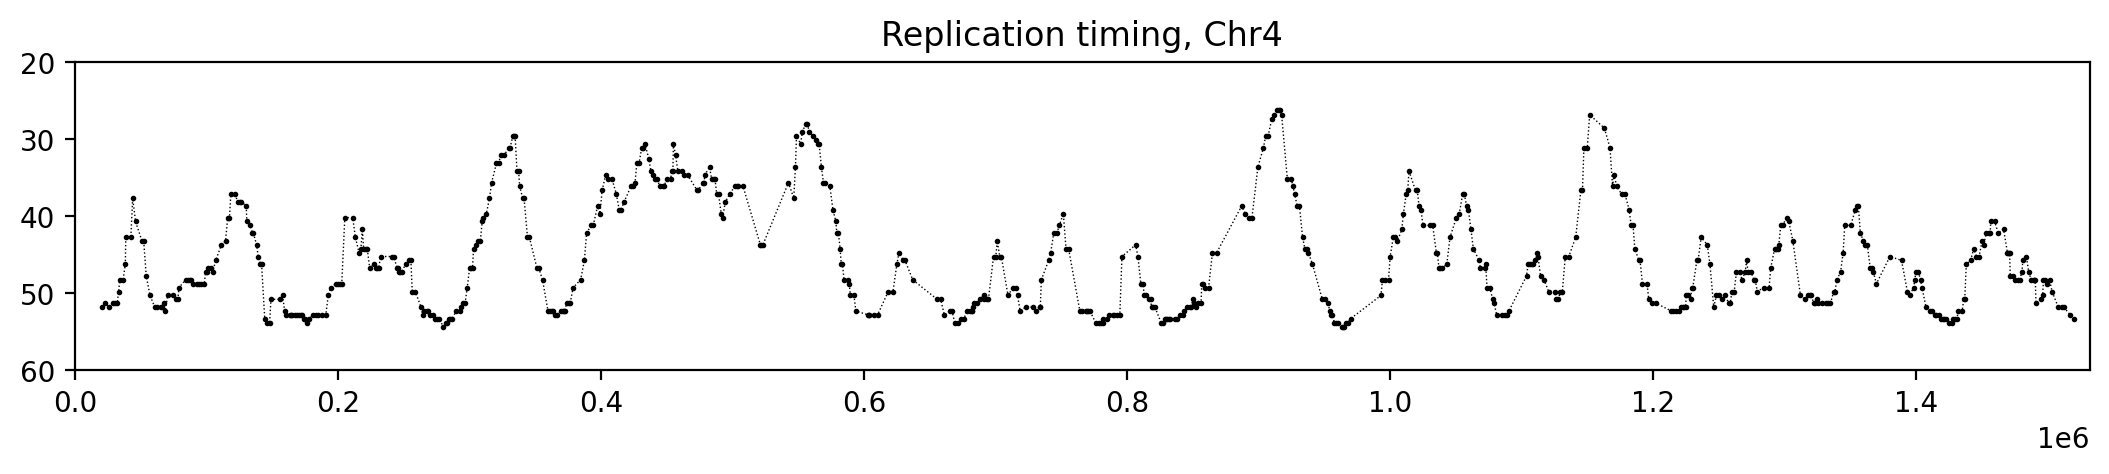

In [4]:
from src.geneset import get_deconvolved_geneset
geneset = get_deconvolved_geneset()

chrom = 4
plot_chrom_repl_timing_from_data(repl_timing, geneset, chrom)

In [5]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.026
1001/5574 - 00:00:05.808
2001/5574 - 00:00:11.996
3001/5574 - 00:00:18.204
4001/5574 - 00:00:24.614
5001/5574 - 00:00:30.787


In [6]:
promoter_analysis.correct_f_images_by_strand()

In [291]:
# Let's get the gene expression at the replication time.

from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()


# Which genes to start with?

Options:

Many genes, all genes compute the chromatin (some delta) before and after replication
- Prior-replication fork
- Post-replication fork

Early vs Late
High vs Low Gene expression


In [606]:
from src.gene_chromatin_replication_analysis import GeneChromatinReplicationAnalysis

gene_chrom_repl_analysis = GeneChromatinReplicationAnalysis(promoter_analysis,
                                                            ge_analysis,
                                                            repl_timing)

5232 genes with replication timing
Shape of the f images:  (5232, 227, 8, 25)


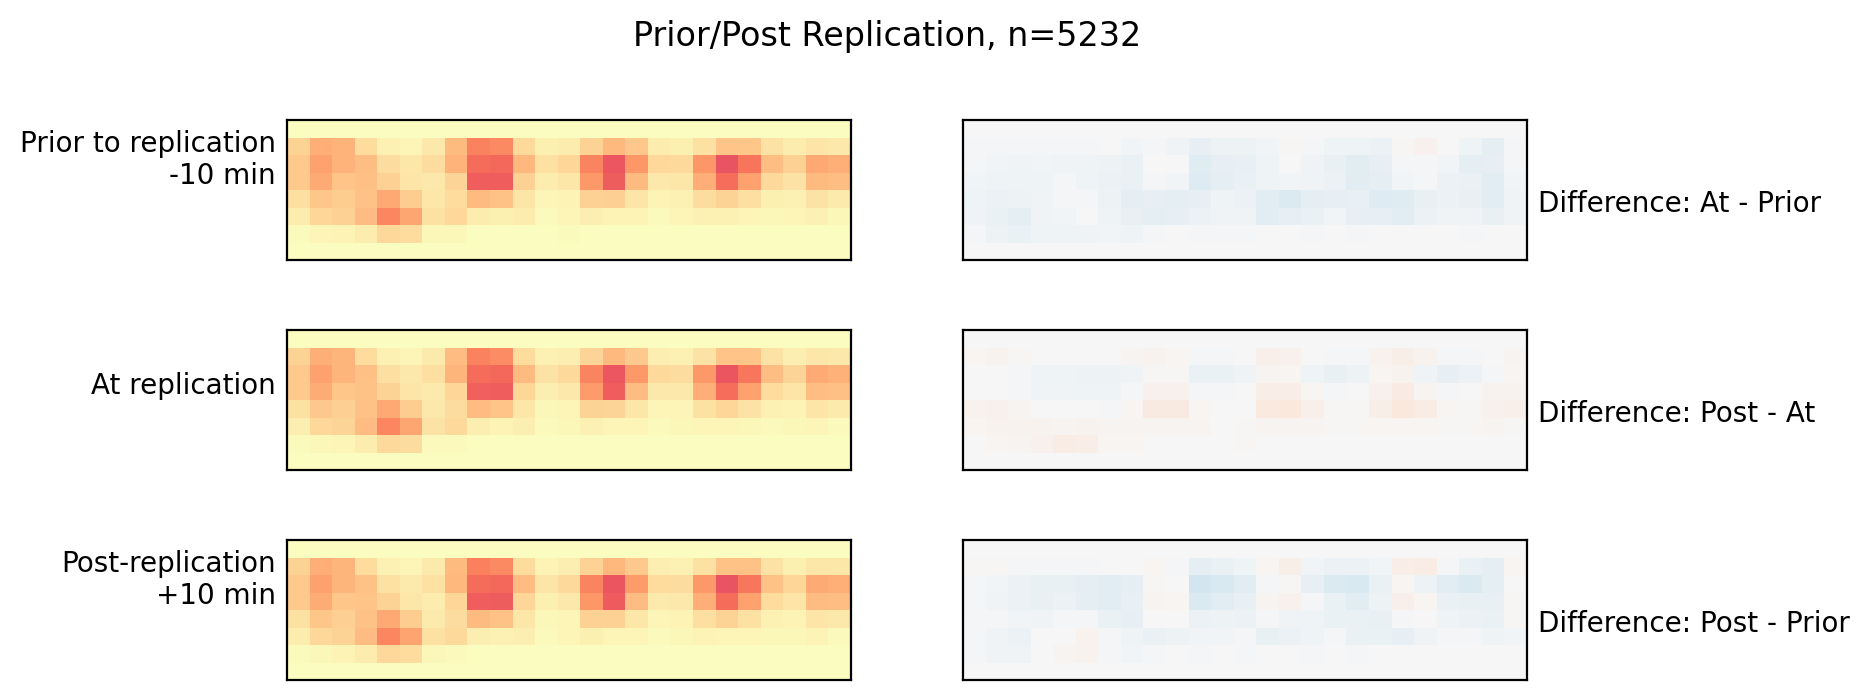

In [577]:
gene_chrom_repl_analysis.select_subset(delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images()

In [371]:
k = 500

sorted_genes_by_replication_exp = gene_chrom_repl_analysis.geneset_repl.\
    sort_values('expression_at_replication', ascending=False)
highly_expressed_orfs = sorted_genes_by_replication_exp.head(k).index.values.astype('str')
lowly_expressed_orfs = sorted_genes_by_replication_exp.tail(k).index.values.astype('str')

sorted_genes_by_replication_exp.head(5)

,gene,TSS,chr,strand,f_gene_index,replication_timing,replication_H_index,expression_at_replication
orf_name,,,,,,,,
YKL060C,FBA1,327512,11,-,2994,31.590485,153,18.741246
YHR174W,ENO2,451298,8,+,2296,40.179085,170,18.682895
YLR249W,YEF3,636741,12,+,3404,39.673885,169,18.653157
YOR063W,RPL3,444665,15,+,4559,36.642585,163,18.131134
YCR012W,PGK1,137707,3,+,510,40.684285,171,18.080586


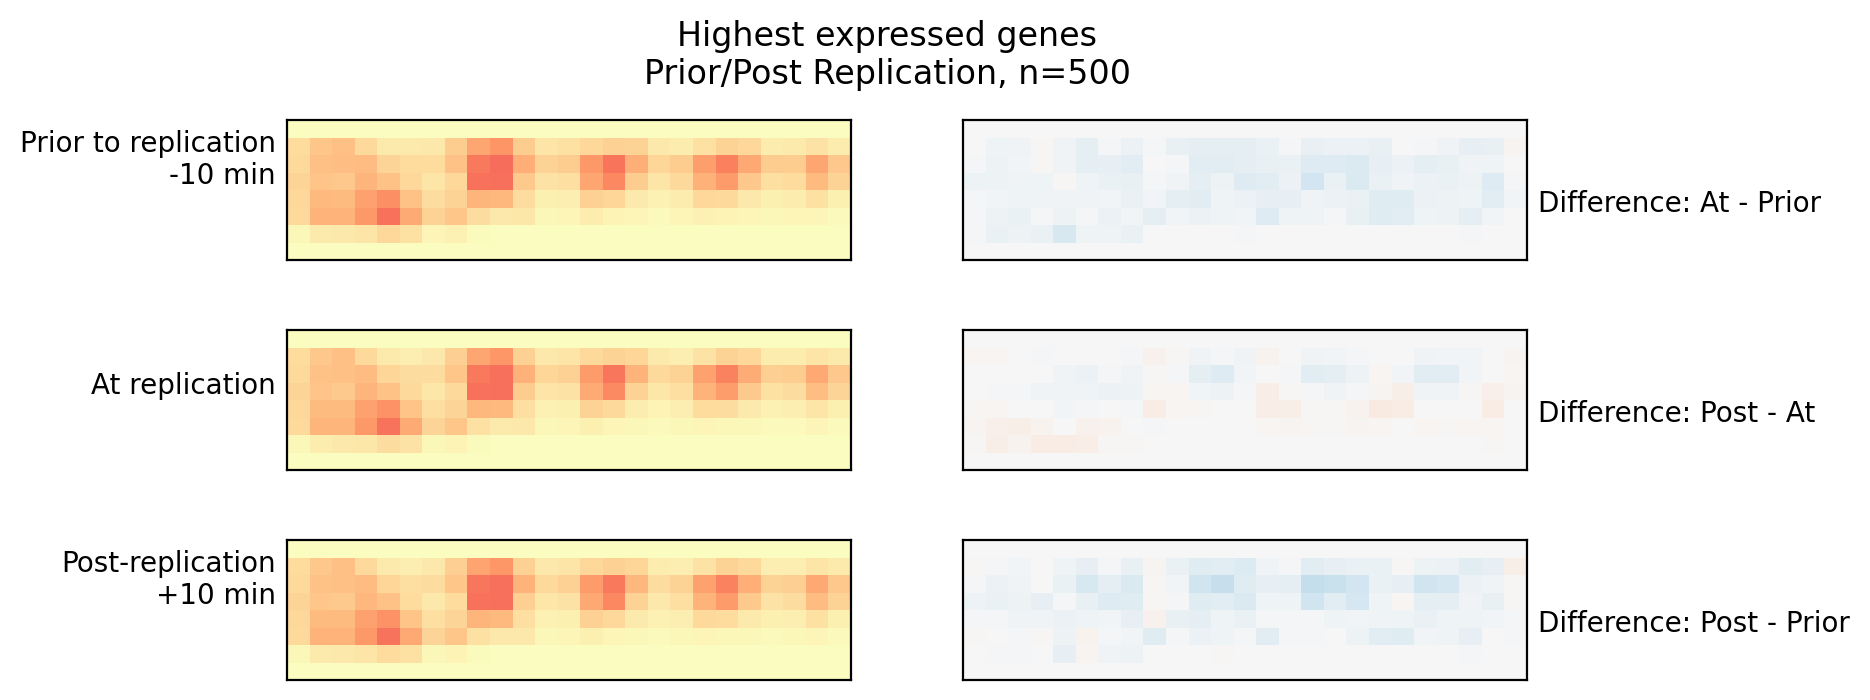

In [578]:
gene_chrom_repl_analysis.select_subset(subset_orfs=highly_expressed_orfs, delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images(title="Highest expressed genes")

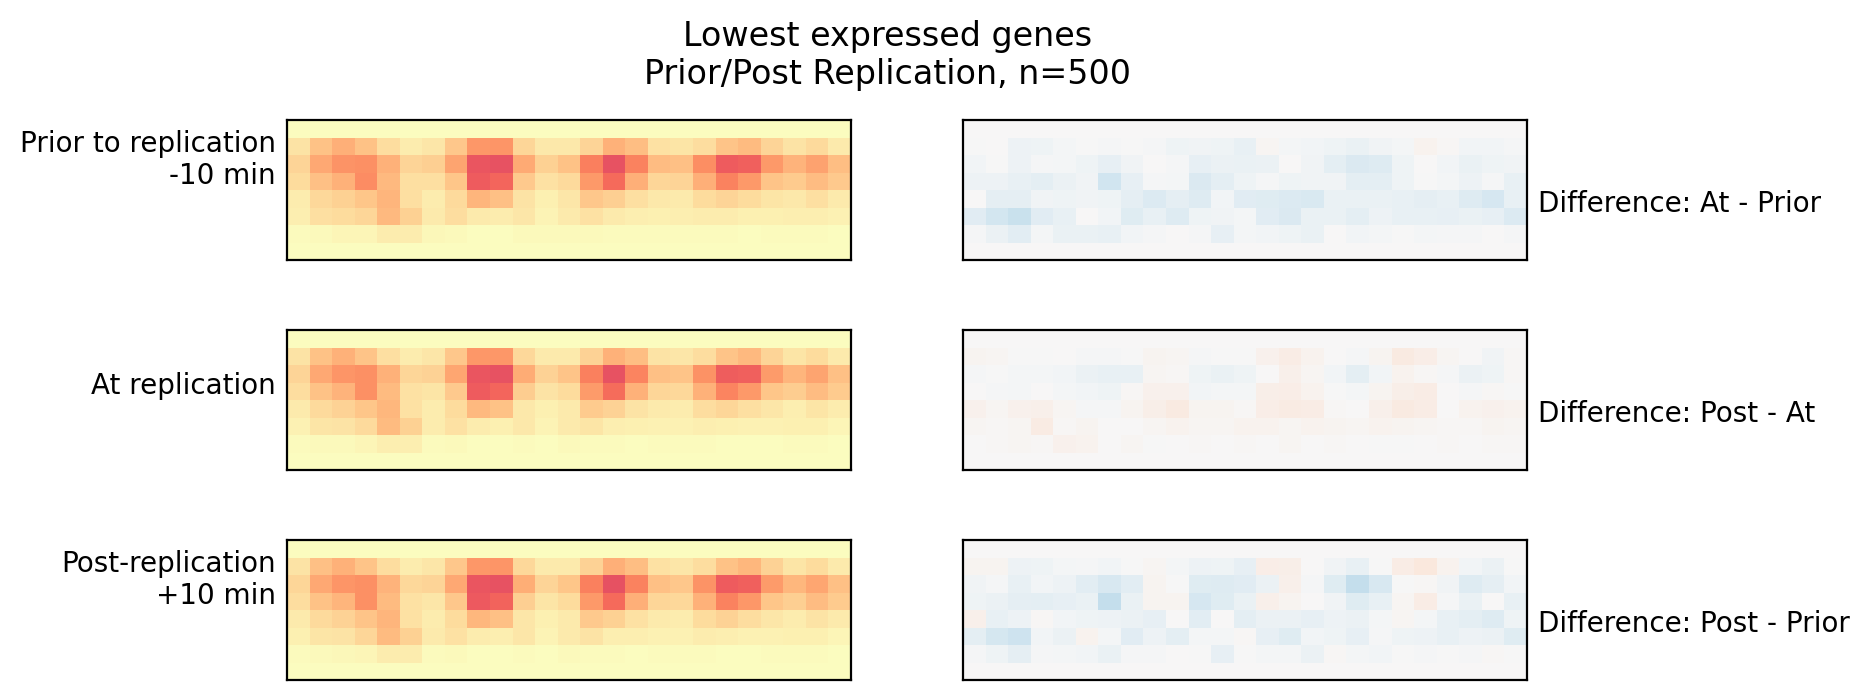

In [579]:
gene_chrom_repl_analysis.select_subset(subset_orfs=lowly_expressed_orfs, delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images(title="Lowest expressed genes")

In [457]:
gene_chrom_repl_analysis.geneset_repl

,gene,TSS,chr,strand,f_gene_index,replication_timing,replication_H_index,expression_at_replication
orf_name,,,,,,,,
YAL067W-A,YAL067W-A,2480,1,+,0,53.314585,196,4.460240
YAL067C,SEO1,9016,1,-,1,52.304185,194,8.783203
YAL064C-A,YAL064C-A,13743,1,-,2,52.809385,195,5.138788
YAL064W,YAL064W,21566,1,+,3,51.798985,193,5.055692
YAL063C-A,YAL063C-A,22685,1,-,4,51.798985,193,5.948723
...,...,...,...,...,...,...,...,...
YPR190C,RPC82,919086,16,-,5227,47.757285,185,11.767971
YPR191W,QCR2,919322,16,+,5228,47.757285,185,12.555180
YPR199C,ARR1,939059,16,-,5229,40.179085,170,9.752150


0

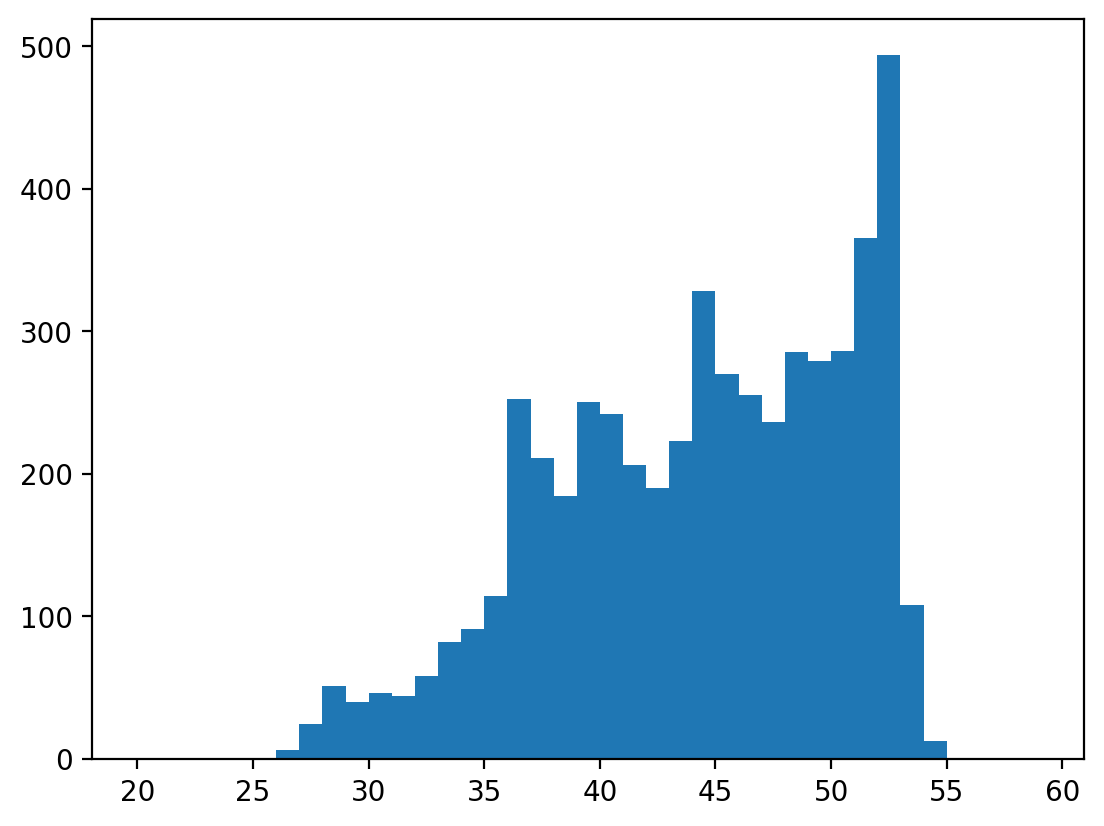

In [431]:
# Is the subtle differences in chromatin due to copy number and normalization?
# Will need to understand the better the implications of normalizing by copy number
# Perhaps Early vs Late replicating gene separation will help make sense of that idea.
repl_timing_values = gene_chrom_repl_analysis.geneset_repl.sort_values('replication_timing')\
    .replication_timing
plt.hist(repl_timing_values, bins=np.arange(20, 60))
0

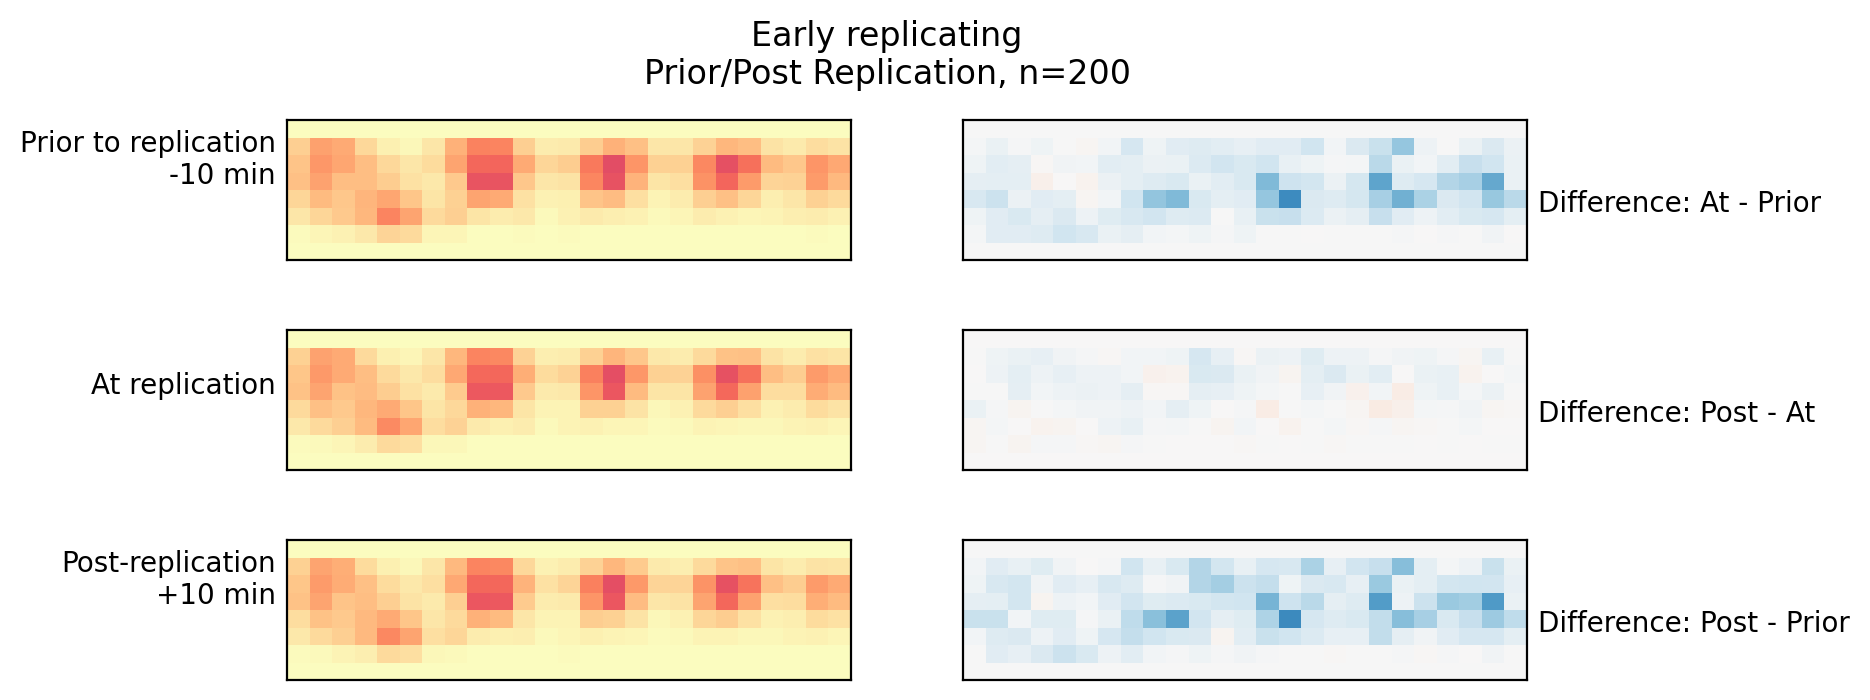

In [580]:
k = 200

gene_chrom_repl_analysis.select_subset(subset_orfs=repl_timing_values.head(k).index, 
                                       delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images(title="Early replicating")

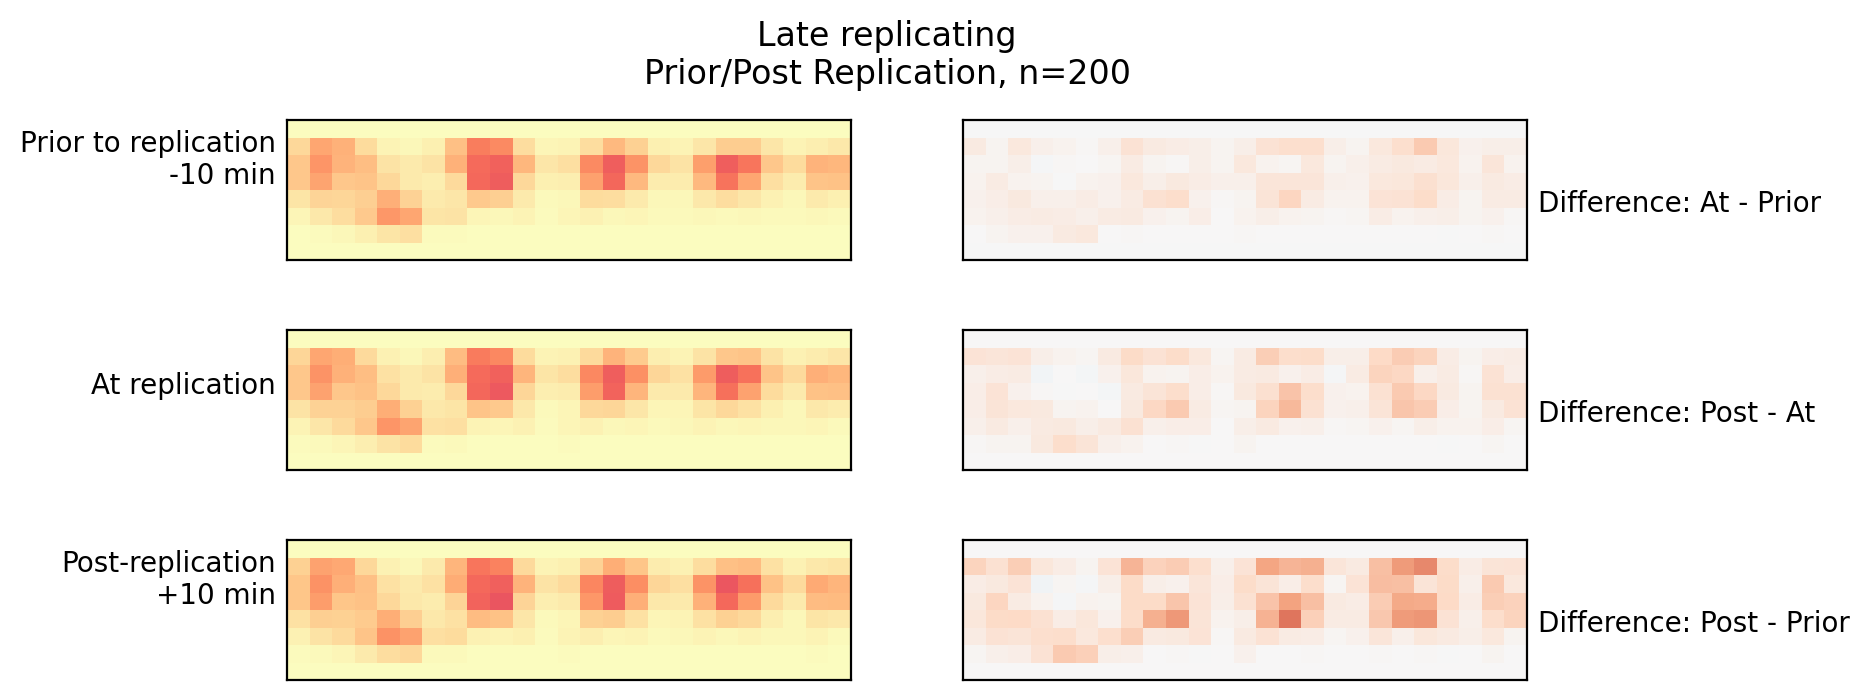

In [581]:
gene_chrom_repl_analysis.select_subset(subset_orfs=repl_timing_values.tail(k).index, 
                                       delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images(title="Late replicating")

In [ ]:
# Is there a way to expand on the idea that I am seeing a propagation of new nucleosomes
# across the genome as regions of the genome are being replicated at different rates?


Text(0, 0.5, 'Expression at replication time, VST')

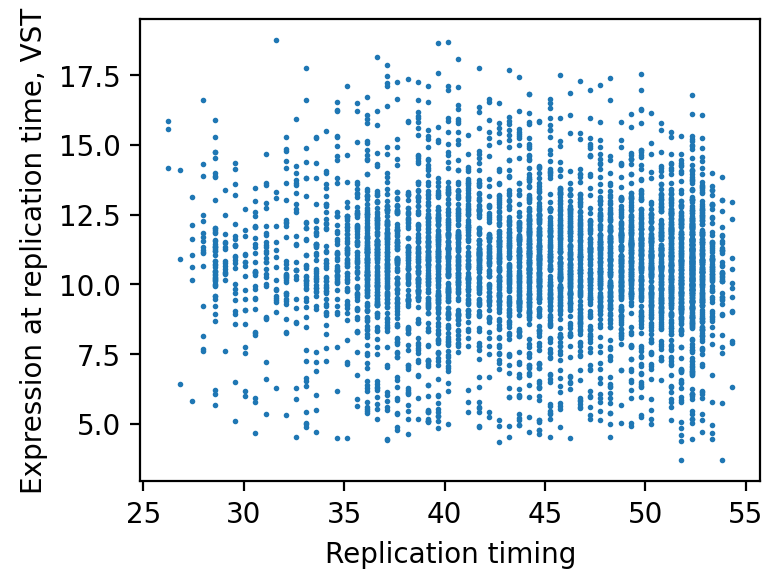

In [541]:
# How is this going to be affected by highly transcribed genes?
geneset_repl = gene_chrom_repl_analysis.geneset_repl

x = geneset_repl.replication_timing
y = geneset_repl.expression_at_replication
plt.figure(figsize=(4, 3))
plt.scatter(x, y, s=1)

plt.xlabel("Replication timing")
plt.ylabel("Expression at replication time, VST")

In [553]:
highly_expressed_repl = geneset_repl.loc[highly_expressed_orfs].sort_values('replication_timing', 
    ascending=True)

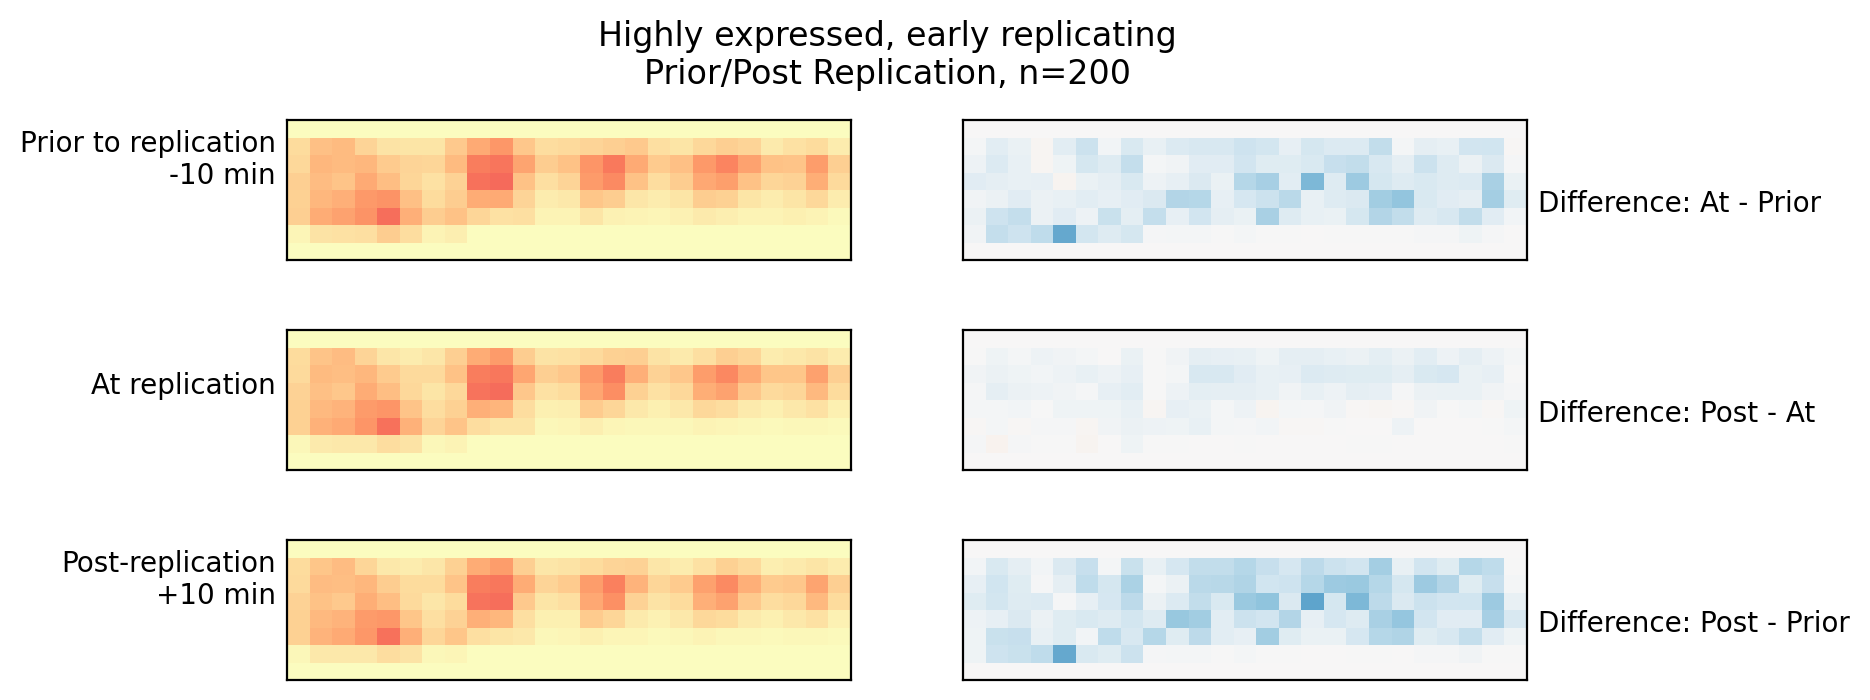

In [582]:
k = 200
gene_chrom_repl_analysis.select_subset(subset_orfs=highly_expressed_repl.head(k).index, 
                                       delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images(title="Highly expressed, early replicating")


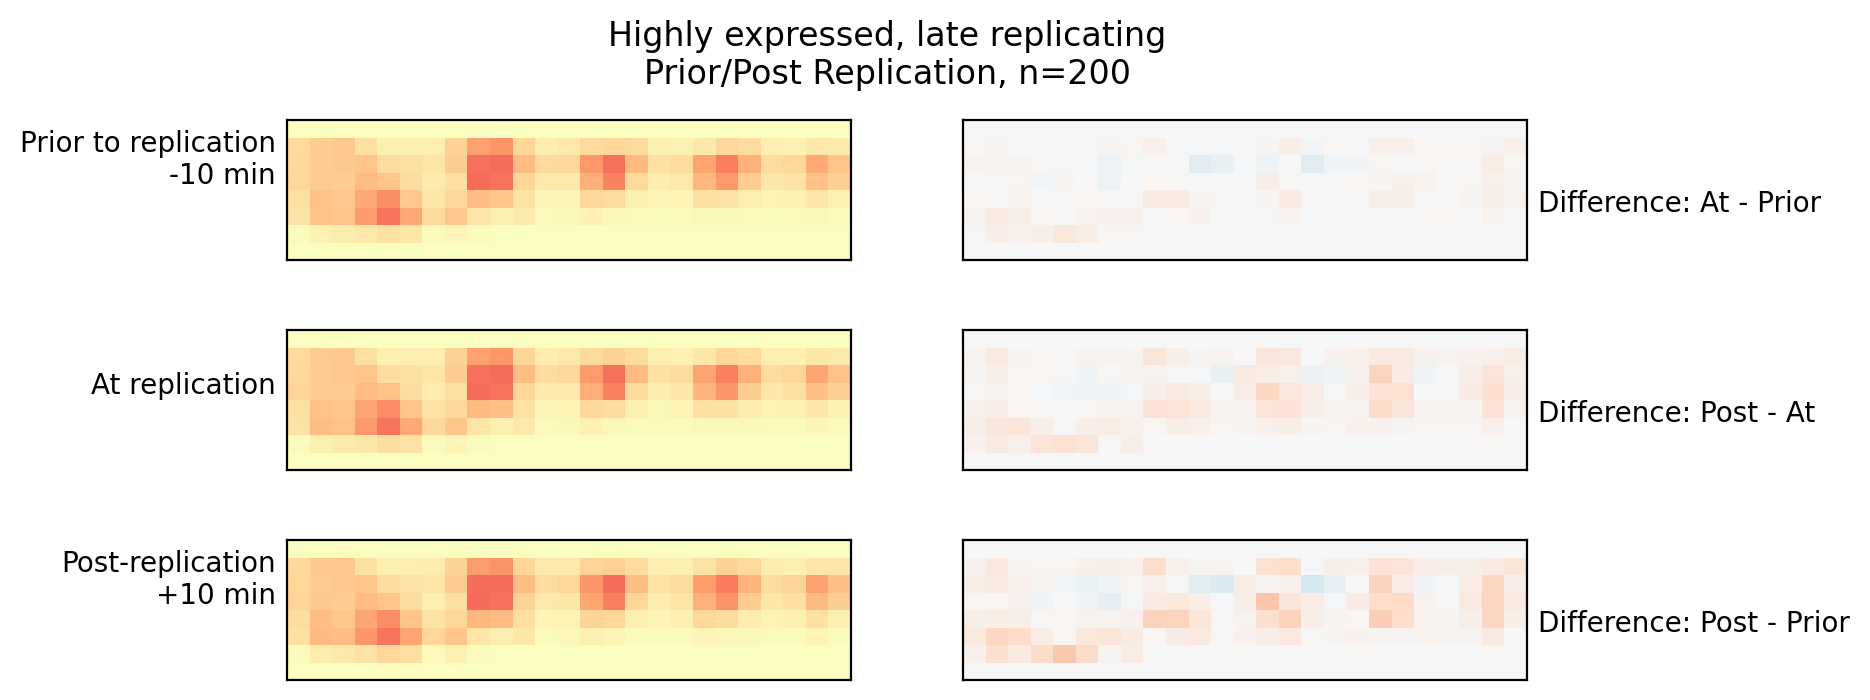

In [583]:
k = 200
gene_chrom_repl_analysis.select_subset(subset_orfs=highly_expressed_repl.tail(k).index, 
                                       delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images(title="Highly expressed, late replicating")


In [561]:
lowly_expressed_repl = geneset_repl.loc[lowly_expressed_orfs].sort_values('replication_timing', 
    ascending=True)

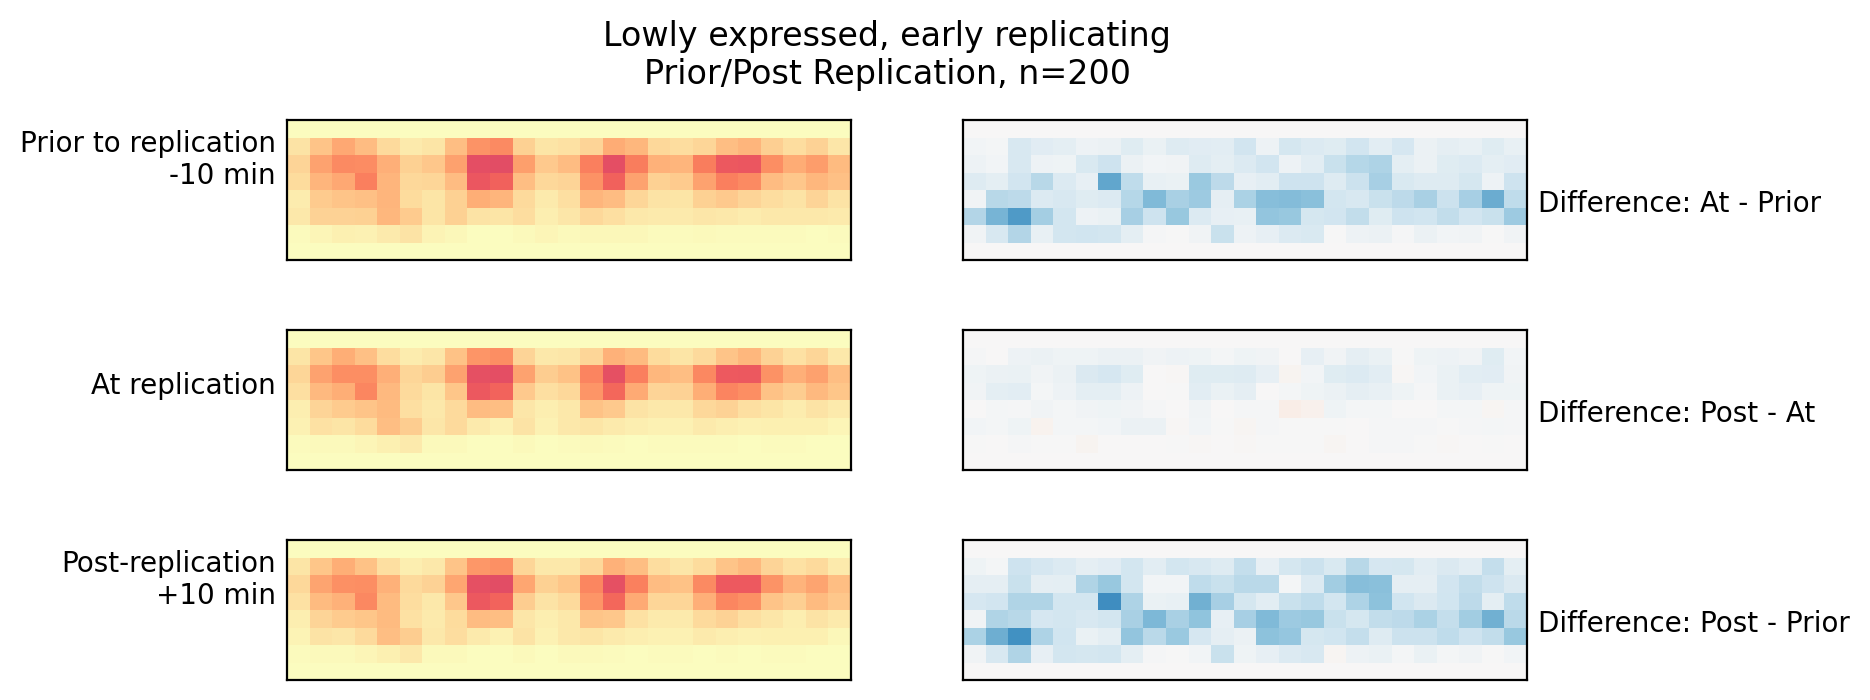

In [584]:
k = 200
gene_chrom_repl_analysis.select_subset(subset_orfs=lowly_expressed_repl.head(k).index, 
                                       delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images(title="Lowly expressed, early replicating")


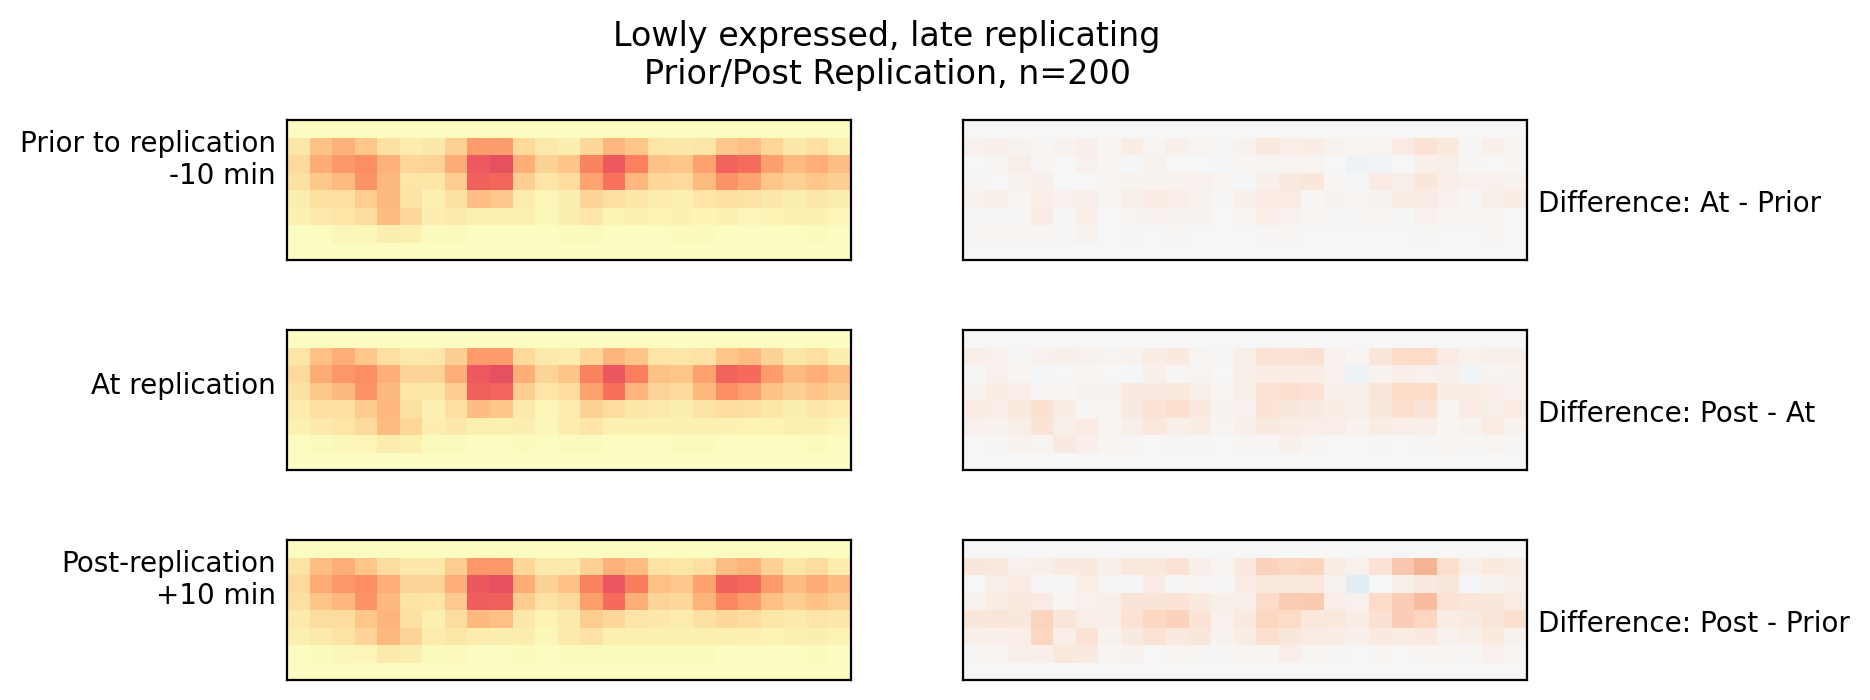

In [585]:
gene_chrom_repl_analysis.select_subset(subset_orfs=lowly_expressed_repl.tail(k).index, 
                                       delta_index=20)
gene_chrom_repl_analysis.plot_pre_post_images(title="Lowly expressed, late replicating")


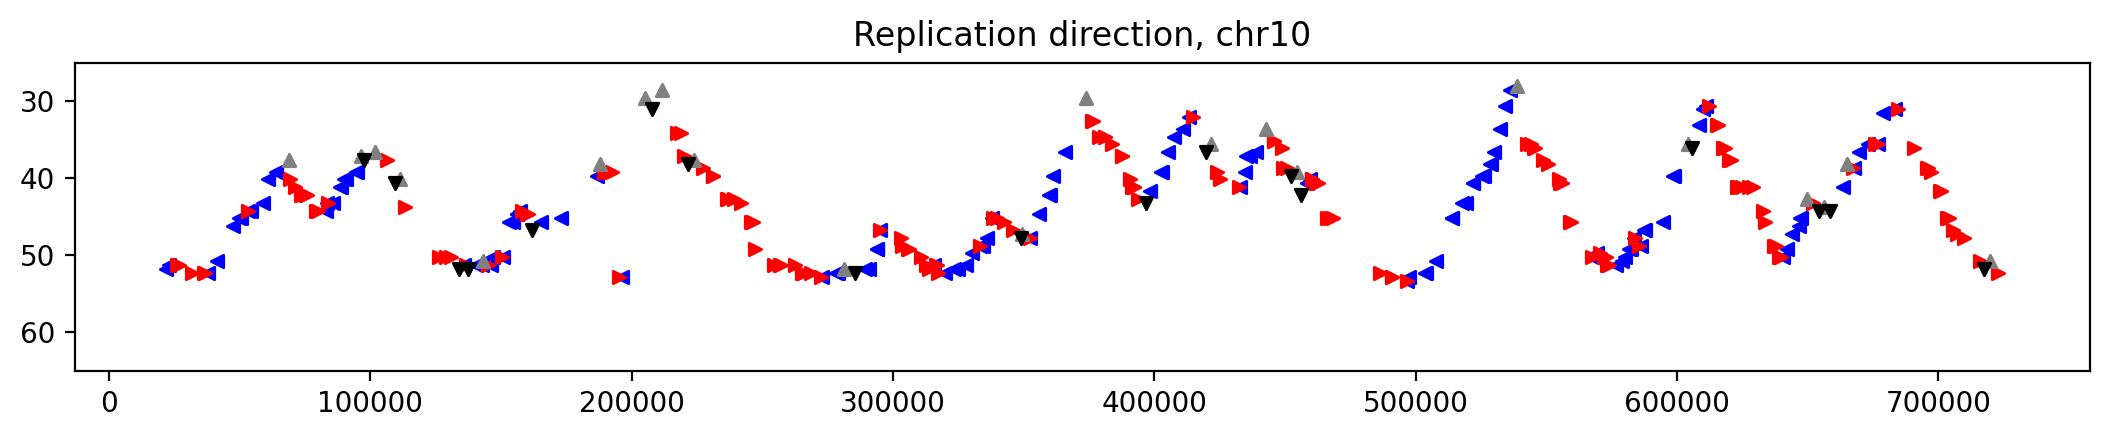

In [619]:
gene_chrom_repl_analysis.plot_replication_direction(10)


In [661]:
# Level of expression doesn't change this story much, but it does show
# the positioning differences in the nucleosomes between highly and lowly expressed
# genes

# Replication and gene expression show explain two signals in the
# highly and lowly expressed genes:
#   1. Positional stability of nucleosomes related to expression
#   2. Overall increase/decrease in reads related to early vs late replication

geneset_repl = gene_chrom_repl_analysis.geneset_repl

# Filter for highly expressed
geneset_repl = geneset_repl[geneset_repl.expression_at_replication > 12]

watson_right = geneset_repl[(geneset_repl.replication_direction == 'right') &
                            (geneset_repl.strand == '+')]
watson_left = geneset_repl[(geneset_repl.replication_direction == 'left') &
                            (geneset_repl.strand == '+')]

crick_right = geneset_repl[(geneset_repl.replication_direction == 'right') &
                            (geneset_repl.strand == '-')]
crick_left = geneset_repl[(geneset_repl.replication_direction == 'left') &
                            (geneset_repl.strand == '-')]


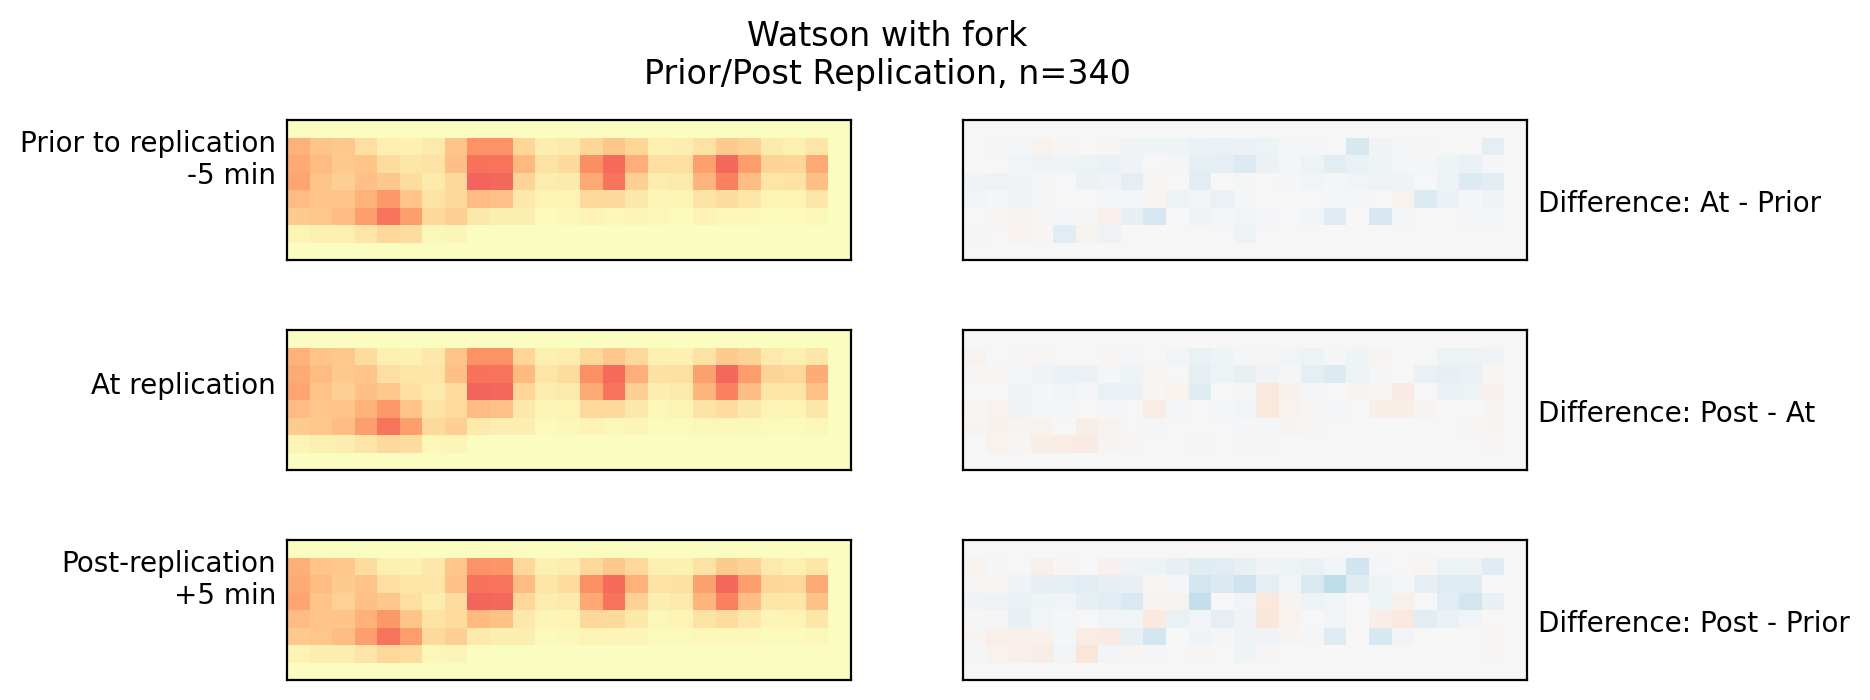

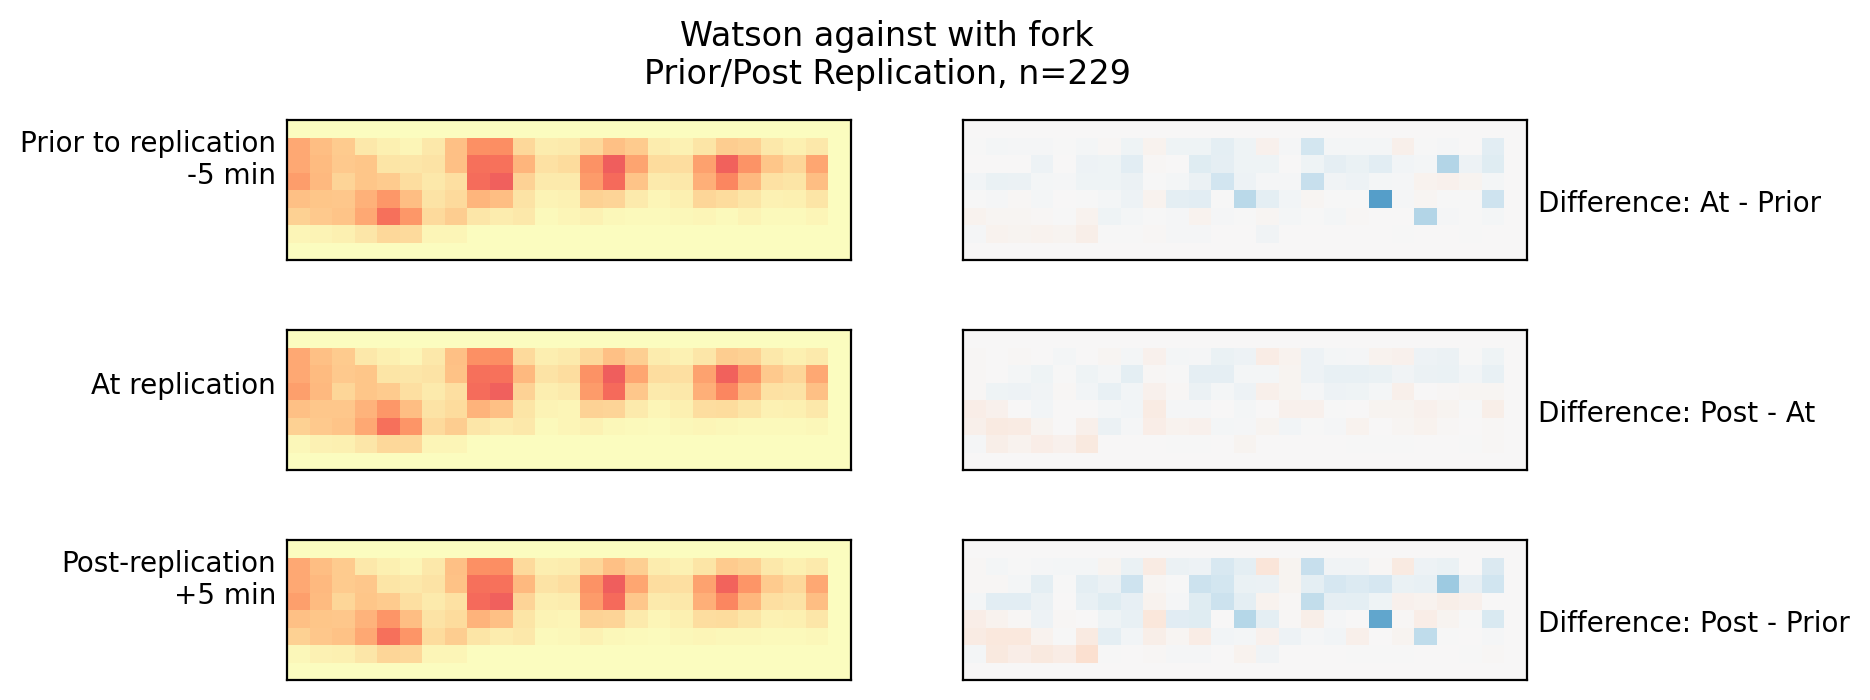

In [662]:
# Last analysis: Genes transcribing with replication vs against replication
# Hypothesis: Genes transcribing against replication will show more disruption in nucleosomes
# than with. And this will be more evident in highly expressed genes.
# Unsure if late/early will have an affect on this.

delta_ind = 10

gene_chrom_repl_analysis.select_subset(subset_orfs=watson_right.index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Watson with fork")

gene_chrom_repl_analysis.select_subset(subset_orfs=watson_left.index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Watson against with fork")


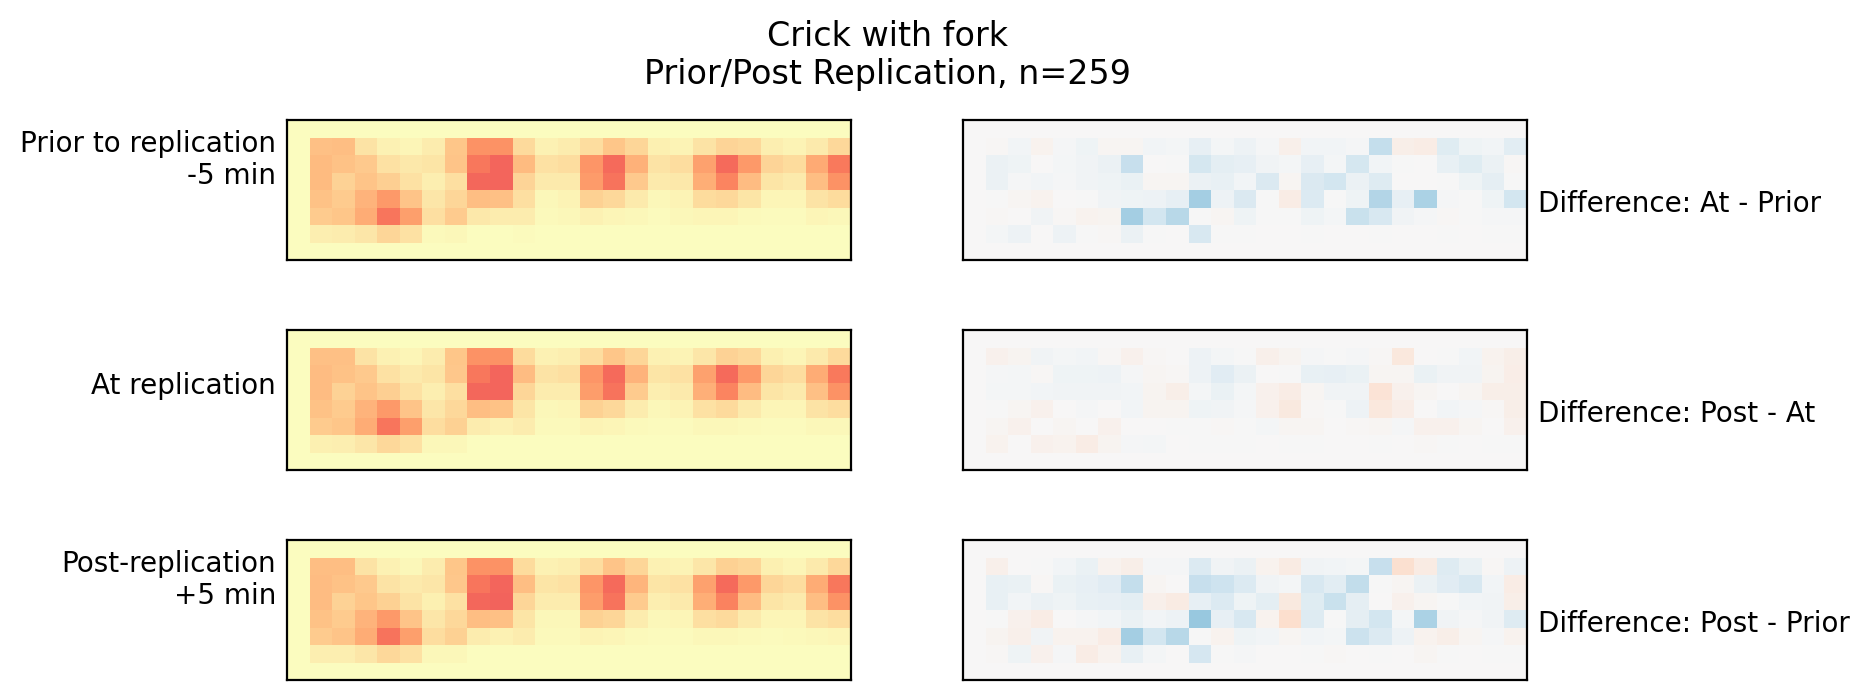

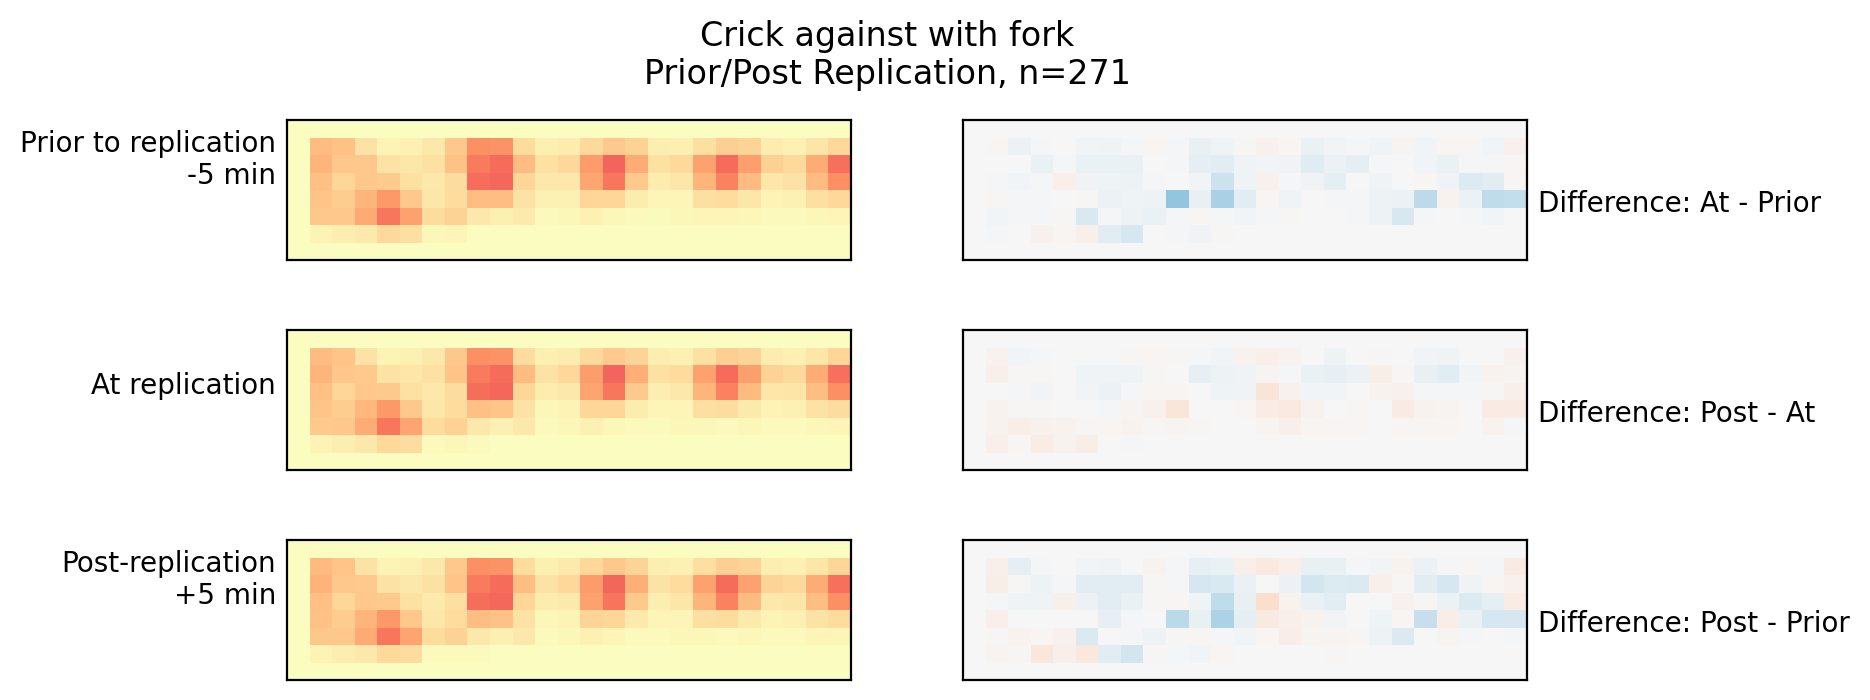

In [663]:
gene_chrom_repl_analysis.select_subset(subset_orfs=crick_left.index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Crick with fork")

gene_chrom_repl_analysis.select_subset(subset_orfs=crick_right.index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Crick against with fork")

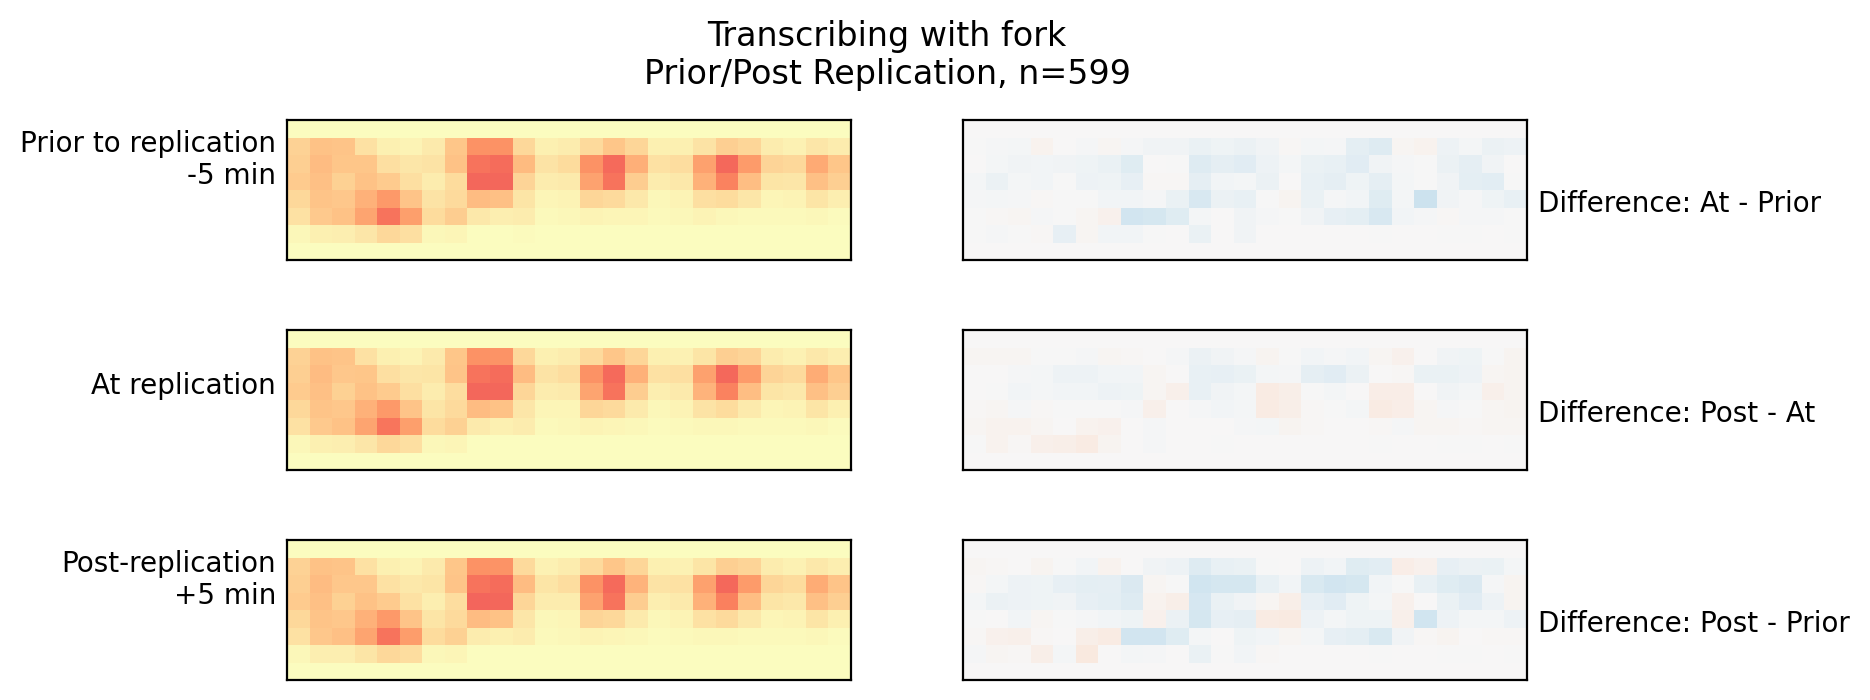

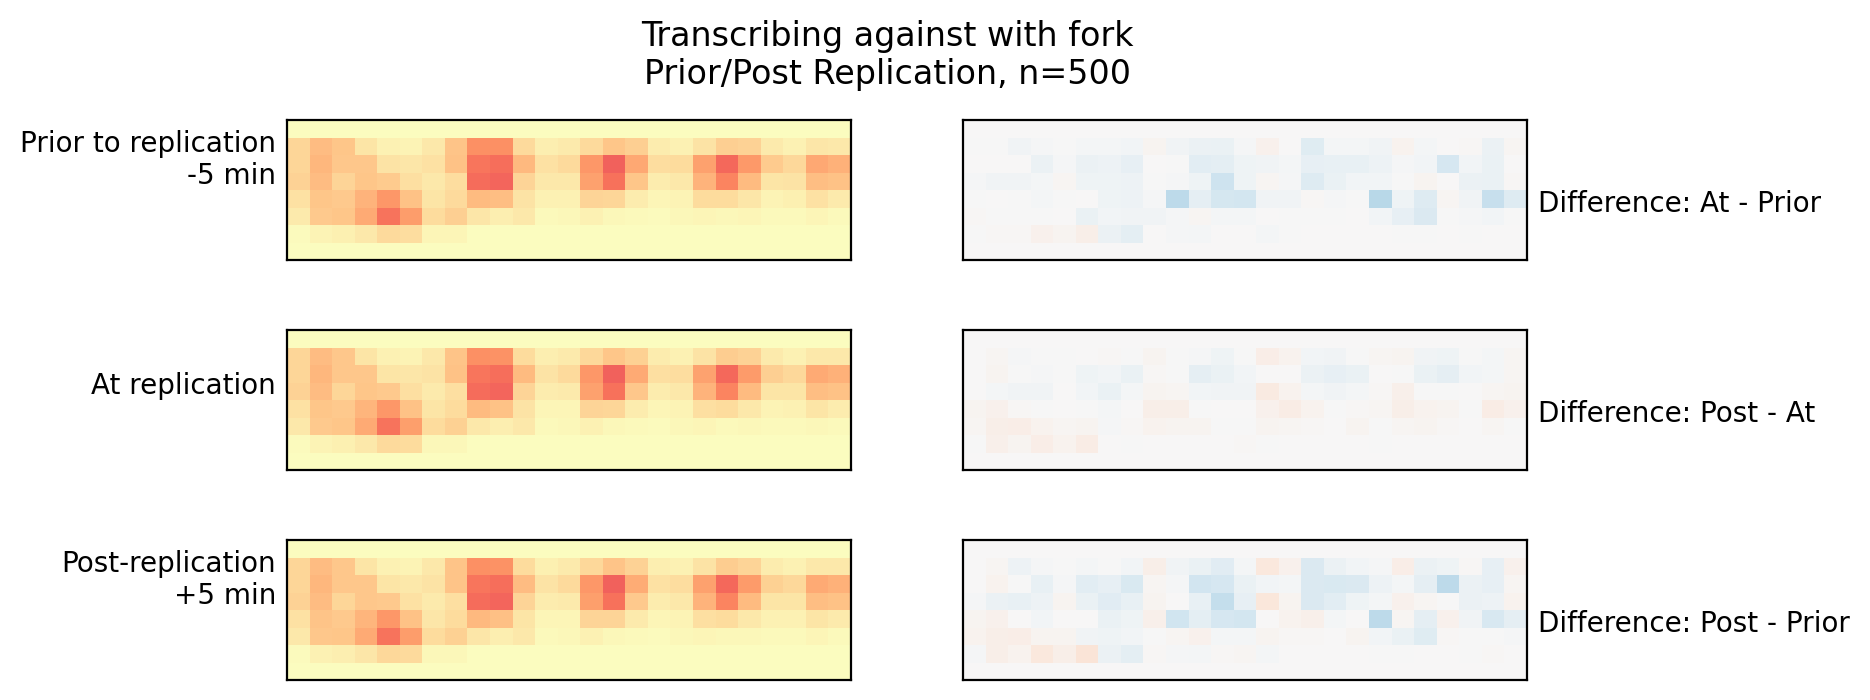

In [664]:

gene_chrom_repl_analysis.select_subset(subset_orfs=np.concatenate([crick_left.index,
                                                                   watson_right.index]), 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Transcribing with fork")

gene_chrom_repl_analysis.select_subset(subset_orfs=np.concatenate([crick_right.index,
                                                                  watson_left.index]), 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Transcribing against with fork")